### Libraries.

In [1]:
from itertools import combinations
import os

import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import seaborn as sns

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Reading the data.

In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Subsampling the data.

In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 5e-3

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 466393 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Applying Transformations to Channel Features.

In [4]:
adata.obsm["X"] = adata.X
COFACTORS = [0.1, 1, 10, 100, 1_000, 10_000]
for cofactor in COFACTORS:
    key_arcsin = f"X_arcsinh_cof{cofactor}"
    key_logabs = f"X_logabs_cof{cofactor}"
    print(f"Applying transformation for {cofactor=}")
    adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
    adata.obsm[key_logabs] = np.sign(adata.X)*np.log(np.abs(adata.X / cofactor))
adata


Applying transformation for cofactor=0.1
Applying transformation for cofactor=1
Applying transformation for cofactor=10
Applying transformation for cofactor=100
Applying transformation for cofactor=1000
Applying transformation for cofactor=10000


AnnData object with n_obs × n_vars = 466393 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X', 'X_arcsinh_cof0.1', 'X_logabs_cof0.1', 'X_arcsinh_cof1', 'X_logabs_cof1', 'X_arcsinh_cof10', 'X_logabs_cof10', 'X_arcsinh_cof100', 'X_logabs_cof100', 'X_arcsinh_cof1000', 'X_logabs_cof1000', 'X_

### Computing Summary Statistics for the Channel Features Data.

In [5]:
# defining function for computing summary statistics
def compute_summary_stats(data):
    output = {}
    stats ={
        "min": np.min, "max": np.max, "mean": np.mean, "median": np.median, "std": np.std
    }
    for idx in range(2):
        output[idx] = {
            stat_id: stat_fn(data, axis=idx) for stat_id, stat_fn in stats.items()
        }
    output[None] = {
        stat_id: stat_fn(data) for stat_id, stat_fn in stats.items()
    }
    return output

summary_stats_dict = {}
summary_stats_dict["X"] = compute_summary_stats(adata.X)
for key, val in adata.obsm.items():
    summary_stats_dict[key] = compute_summary_stats(val)

for key, val in summary_stats_dict.items():
    print(f"Summary stats for {key}:")
    for stats, stats_val in val[None].items():
        print(f"\t{stats}: {stats_val}")


Summary stats for X:
	min: -2176279.25
	max: 4692767.5
	mean: 2031.8056640625
	median: 213.31320190429688
	std: 12609.638671875
Summary stats for X_arcsinh_cof0.1:
	min: -17.58885955810547
	max: 18.35726547241211
	mean: 2.2120680809020996
	median: 8.35849380493164
	std: 9.525086402893066
Summary stats for X_logabs_cof0.1:
	min: -16.89571189880371
	max: 17.66411781311035
	mean: 2.075711250305176
	median: 7.665346622467041
	std: 8.855958938598633
Summary stats for X_arcsinh_cof1:
	min: -15.286273956298828
	max: 16.05467987060547
	mean: 1.7591289281845093
	median: 6.055914402008057
	std: 7.309741497039795
Summary stats for X_logabs_cof1:
	min: -14.593127250671387
	max: 15.361533164978027
	mean: 1.6227538585662842
	median: 5.362794876098633
	std: 6.648433685302734
Summary stats for X_arcsinh_cof10:
	min: -12.983689308166504
	max: 13.752095222473145
	mean: 1.306221604347229
	median: 3.7538726329803467
	std: 5.131227970123291
Summary stats for X_logabs_cof10:
	min: -12.290542602539062
	max: 

### Retrieving the Scatter Features Data.

In [6]:
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
scatter_df = adata_original.obs[SCATTER_COLUMNS]
X_scatter = scatter_df.values
scatter_df


,FSC - Area,FSC - Height,FSC - Width,SSC - Area,SSC - Height,SSC - Width
0-0,342595.843750,172081.0,256.723297,234387.671875,137146.5,220.147018
1-0,338149.406250,184090.5,236.860886,246990.937500,151945.5,209.390015
2-0,463821.656250,227200.5,263.243622,317084.593750,157499.5,259.333588
3-0,349719.812500,192834.0,233.858261,140738.421875,97901.0,185.177551
4-0,303727.312500,166724.0,234.910172,162527.390625,114021.0,183.613464
...,...,...,...,...,...,...
36486-671,320513.000000,162869.5,253.759308,241374.062500,138142.5,225.074402
36487-671,317020.718750,191423.0,213.554947,107036.125000,87157.0,158.194321
36488-671,256884.703125,145514.5,227.639740,194178.687500,132043.5,189.429382
36489-671,305994.343750,166427.5,237.085190,159084.828125,95011.0,215.683868


### Applying Transformations to the Scatter Data.

In [7]:
X_scatter_transformed_dict = {}
COFACTORS = [0.1, 1, 10, 100, 1_000, 10_000]
for cofactor in COFACTORS:
    key_arcsin = f"X_arcsinh_cof{cofactor}"
    key_logabs = f"X_logabs_cof{cofactor}"
    print(f"Applying transformation for {cofactor=}")
    X_scatter_transformed_dict[key_arcsin] = np.arcsinh(X_scatter/cofactor)
    X_scatter_transformed_dict[key_logabs] = np.sign(X_scatter)*np.log(np.abs(X_scatter/cofactor))


Applying transformation for cofactor=0.1
Applying transformation for cofactor=1
Applying transformation for cofactor=10
Applying transformation for cofactor=100
Applying transformation for cofactor=1000
Applying transformation for cofactor=10000


### Computing Summary Statistics.

In [8]:
scatter_summary_stats_dict = {}
scatter_summary_stats_dict["X_scatter"] = compute_summary_stats(X_scatter)

for key, val in X_scatter_transformed_dict.items():
    scatter_summary_stats_dict[key] = compute_summary_stats(val)

for key, val in scatter_summary_stats_dict.items():
    print(f"Summary stats for {key}:")
    for stats, stats_val in val[None].items():
        print(f"\t{stats}: {stats_val}")


Summary stats for X_scatter:
	min: 92.30398559570312
	max: 16667798.0
	mean: 161952.9375
	median: 156506.5
	std: 152185.703125
Summary stats for X_arcsinh_cof0.1:
	min: 7.520819664001465
	max: 19.62472152709961
	mean: 13.007457733154297
	median: 14.956584930419922
	std: 3.2431201934814453
Summary stats for X_logabs_cof0.1:
	min: 6.827672481536865
	max: 18.93157386779785
	mean: 12.31473445892334
	median: 14.26343822479248
	std: 3.243129253387451
Summary stats for X_arcsinh_cof1:
	min: 5.218263626098633
	max: 17.32213592529297
	mean: 10.70400333404541
	median: 12.654000282287598
	std: 3.243117332458496
Summary stats for X_logabs_cof1:
	min: 4.525087356567383
	max: 16.62898826599121
	mean: 10.011225700378418
	median: 11.96085262298584
	std: 3.24312162399292
Summary stats for X_arcsinh_cof10:
	min: 2.9185707569122314
	max: 15.019551277160645
	mean: 8.401941299438477
	median: 10.351414680480957
	std: 3.242899179458618
Summary stats for X_logabs_cof10:
	min: 2.2225022315979004
	max: 14.32640

### Correlations.

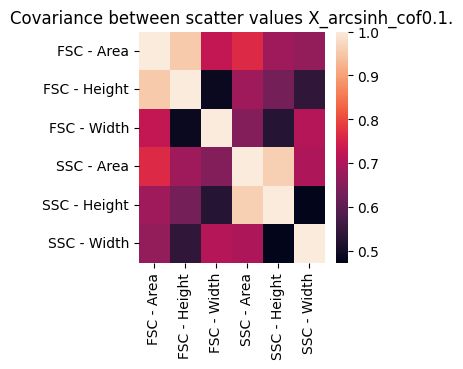

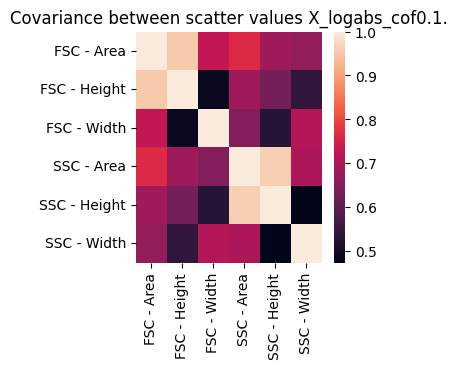

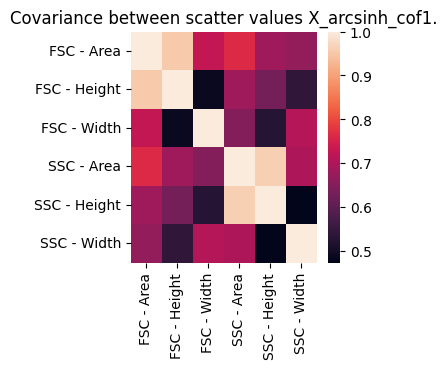

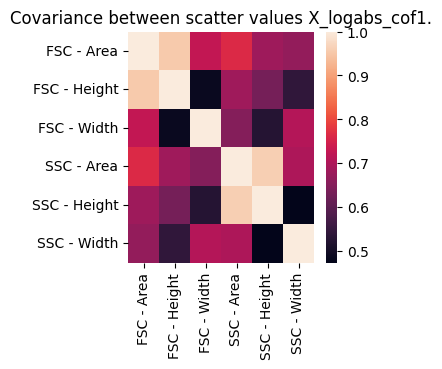

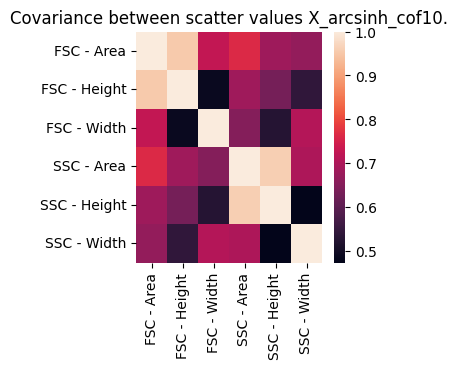

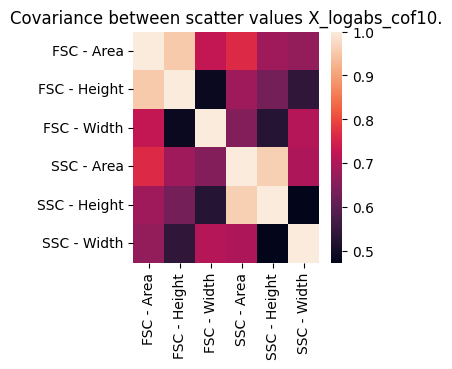

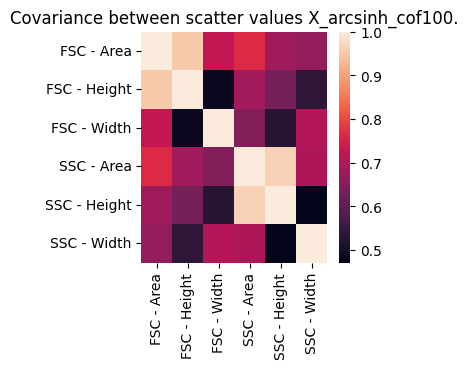

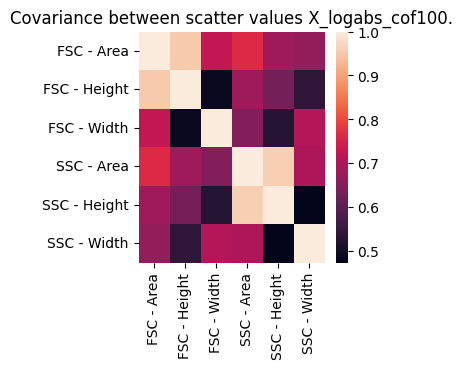

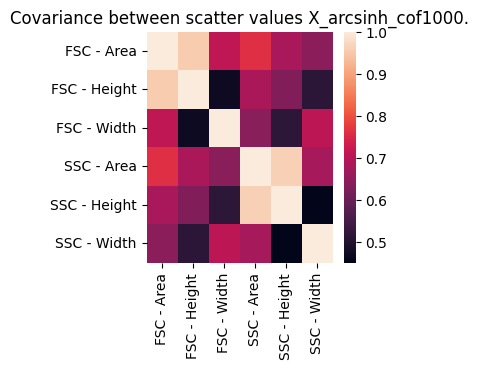

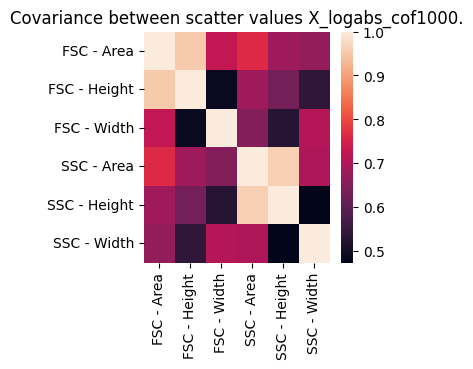

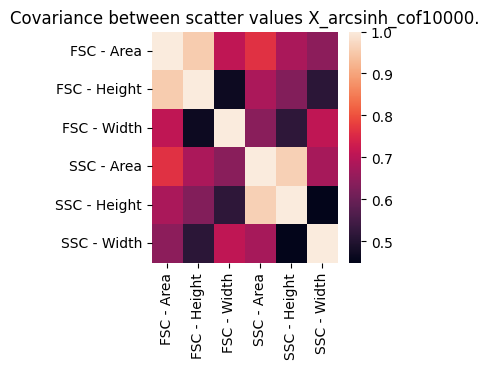

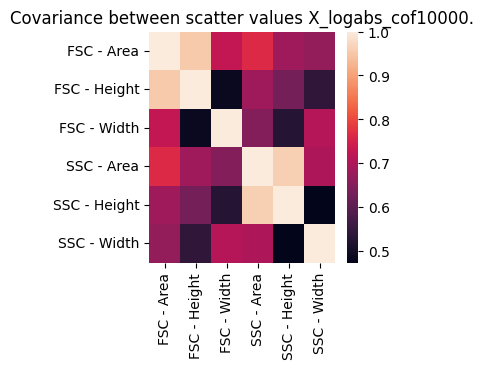

In [9]:
for key, value in X_scatter_transformed_dict.items():
    corr_antibodies = np.corrcoef(value.T)
    plt.figure()
    sns.heatmap(corr_antibodies, fmt='d', xticklabels=SCATTER_COLUMNS, yticklabels=SCATTER_COLUMNS)
    plt.title(f"Covariance between scatter values {key}.")


### Histogram of scatter values.

X_arcsinh_cof0.1
X_logabs_cof0.1
X_arcsinh_cof1
X_logabs_cof1
X_arcsinh_cof10
X_logabs_cof10
X_arcsinh_cof100
X_logabs_cof100
X_arcsinh_cof1000
X_logabs_cof1000
X_arcsinh_cof10000
X_logabs_cof10000


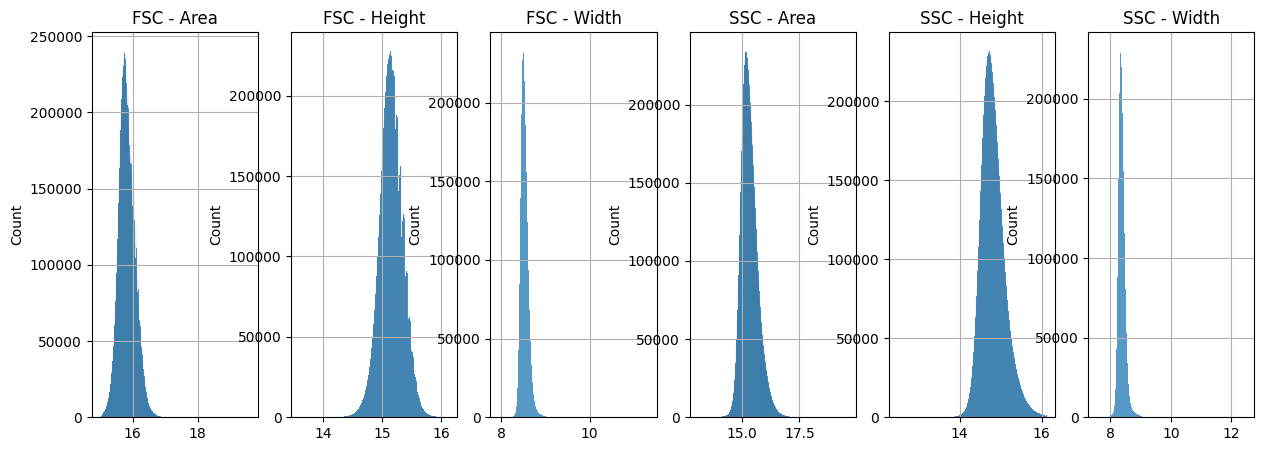

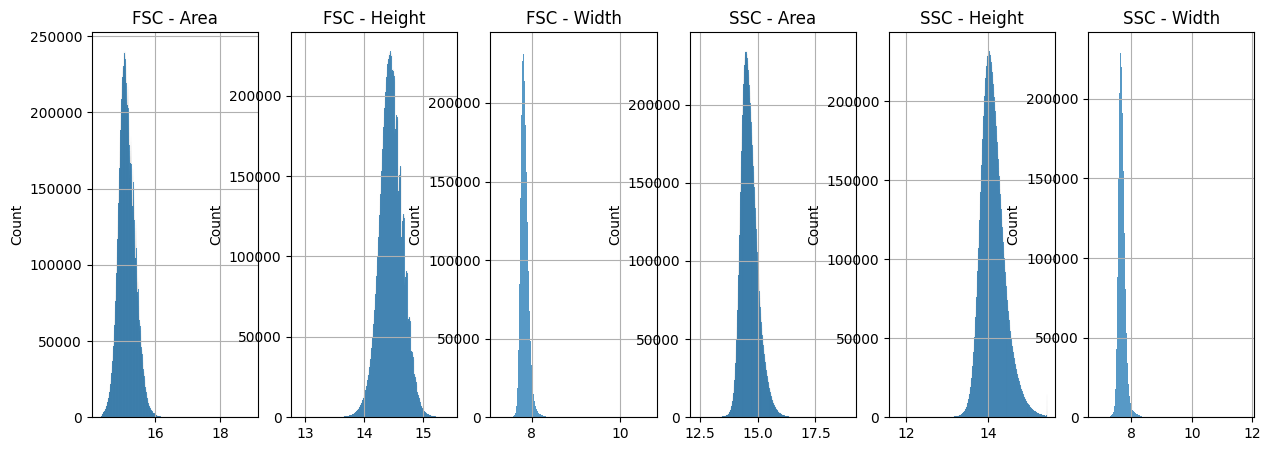

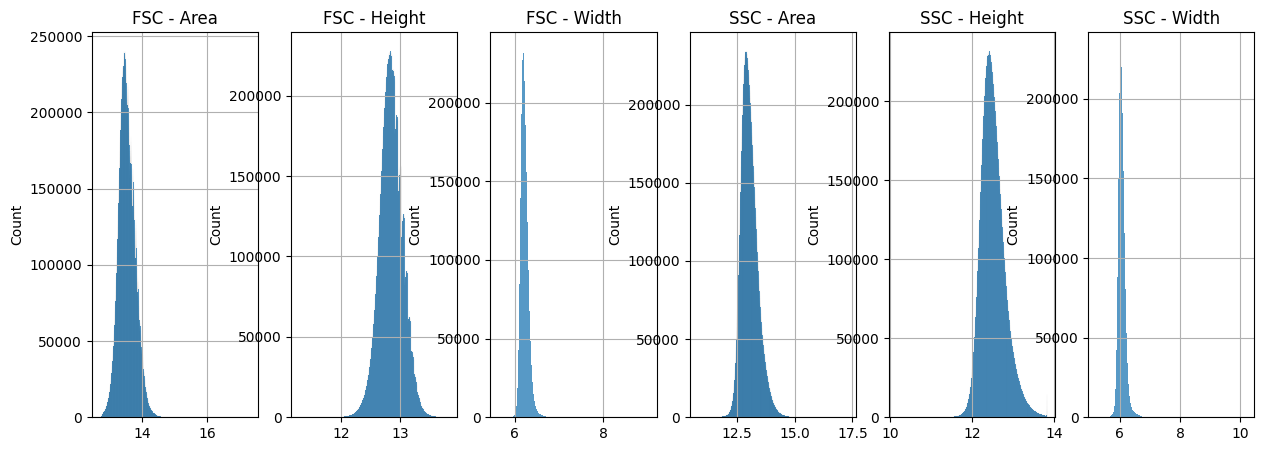

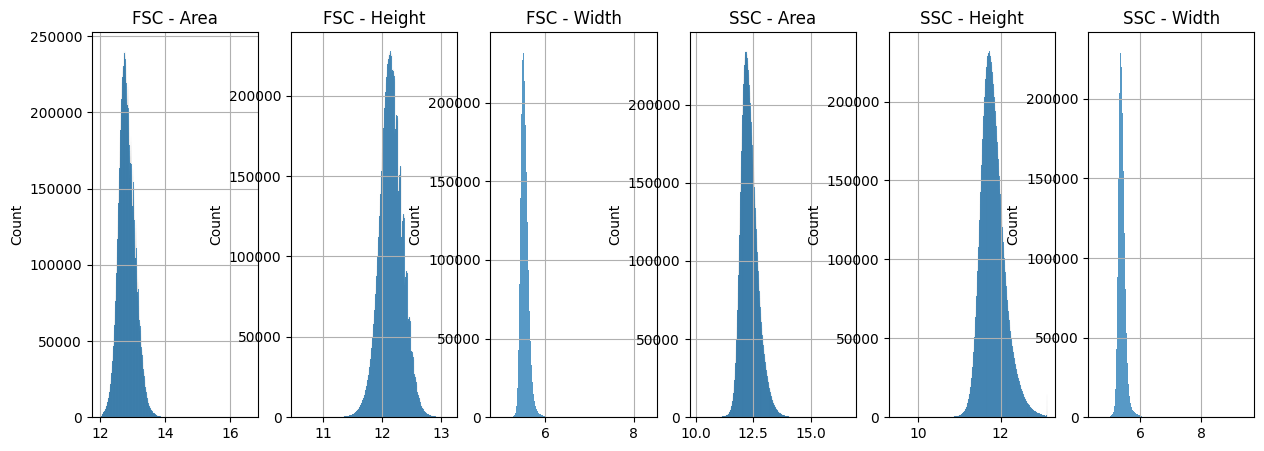

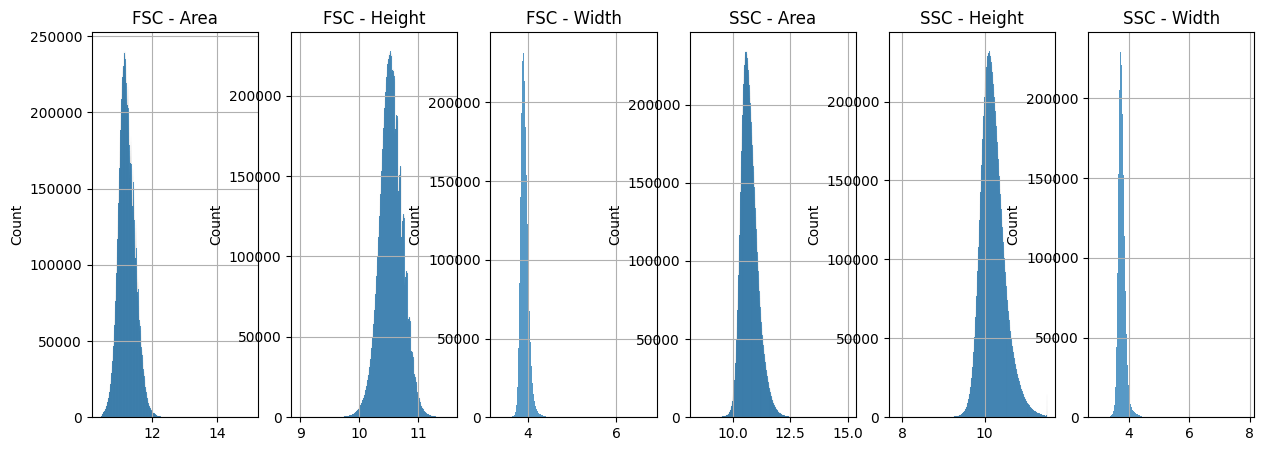

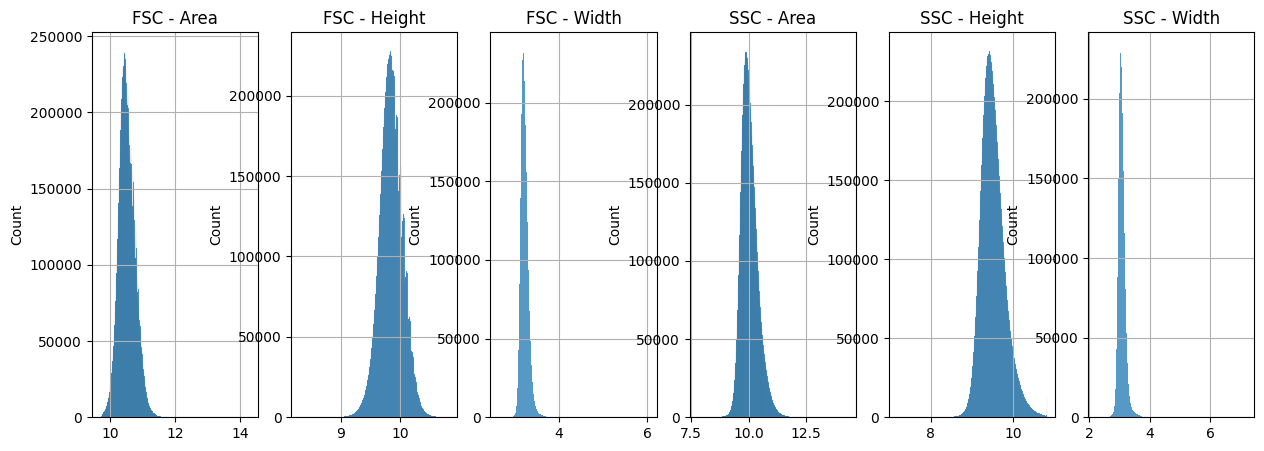

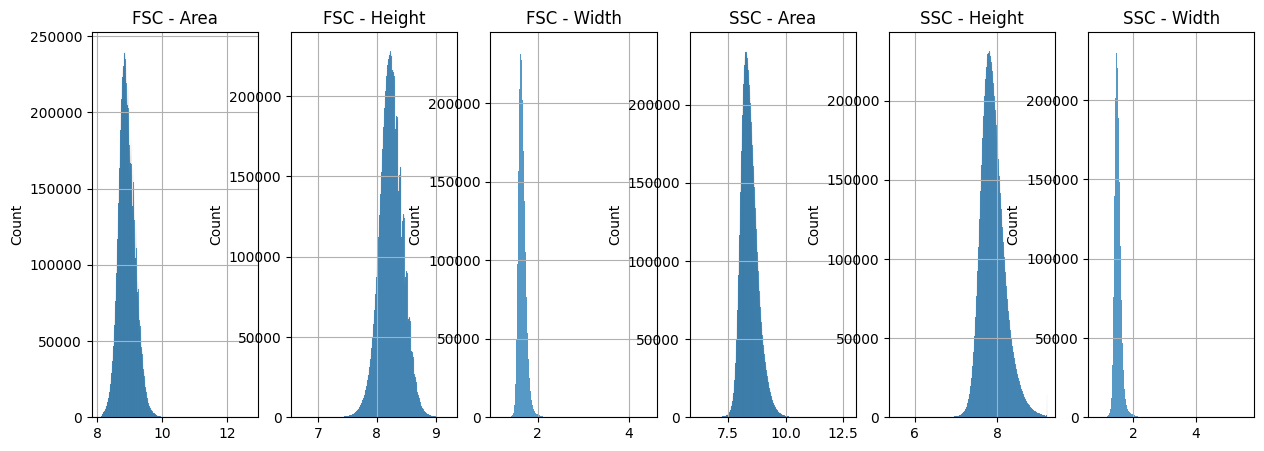

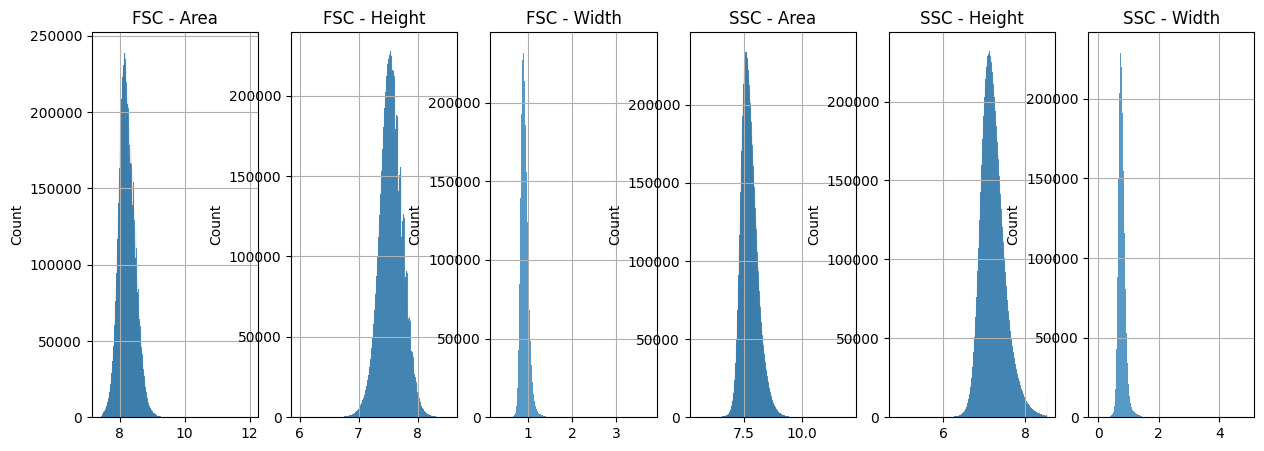

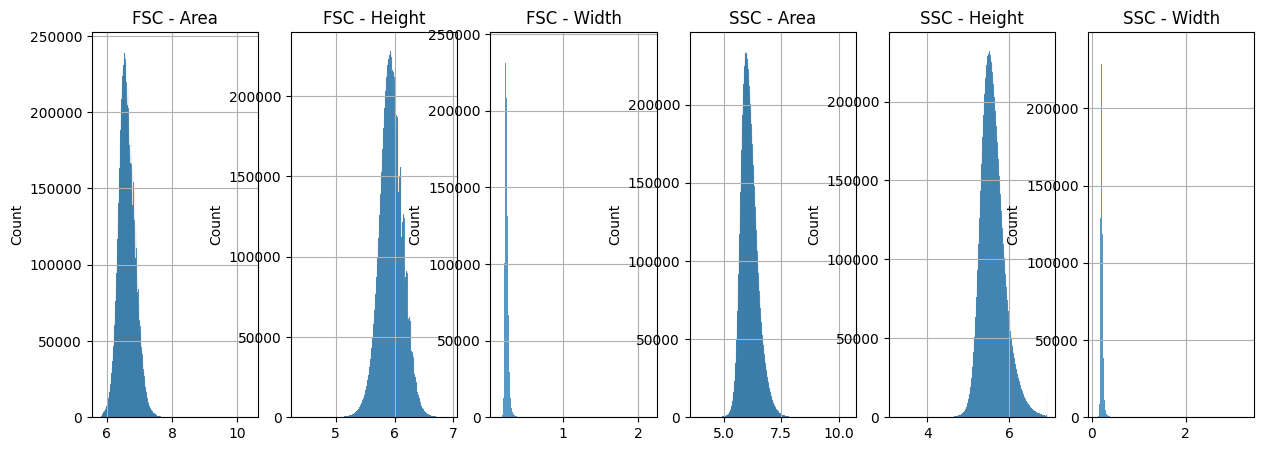

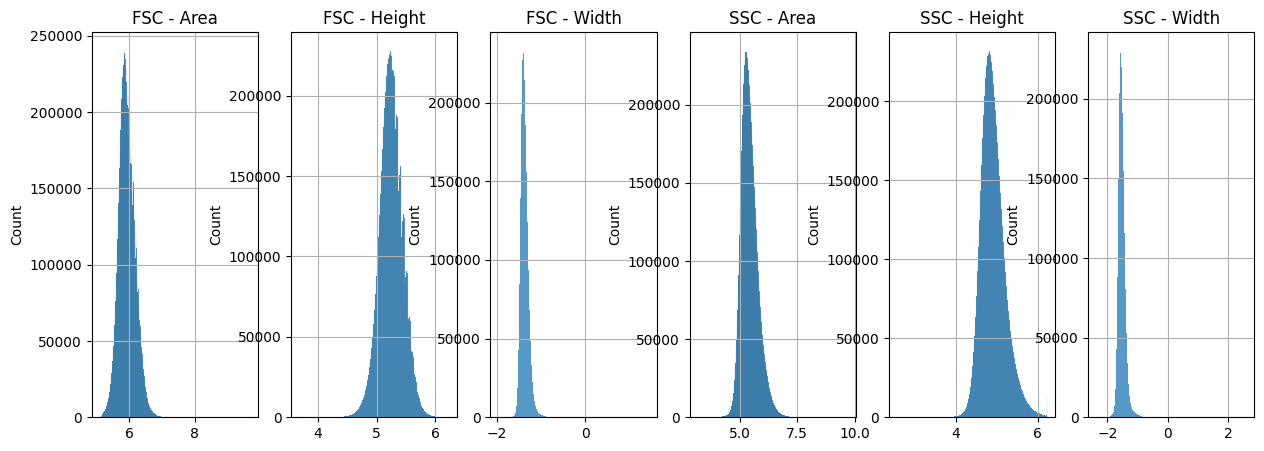

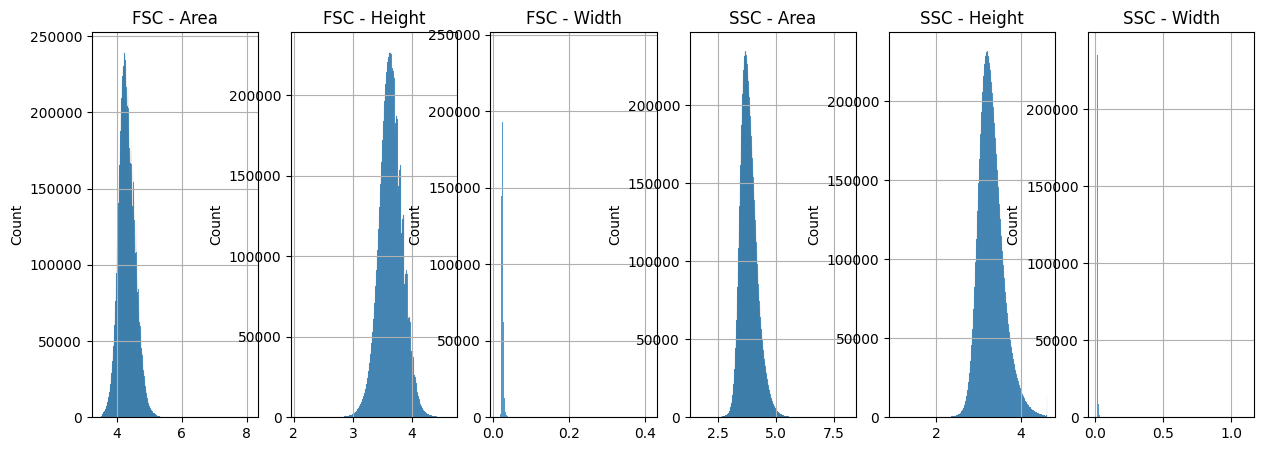

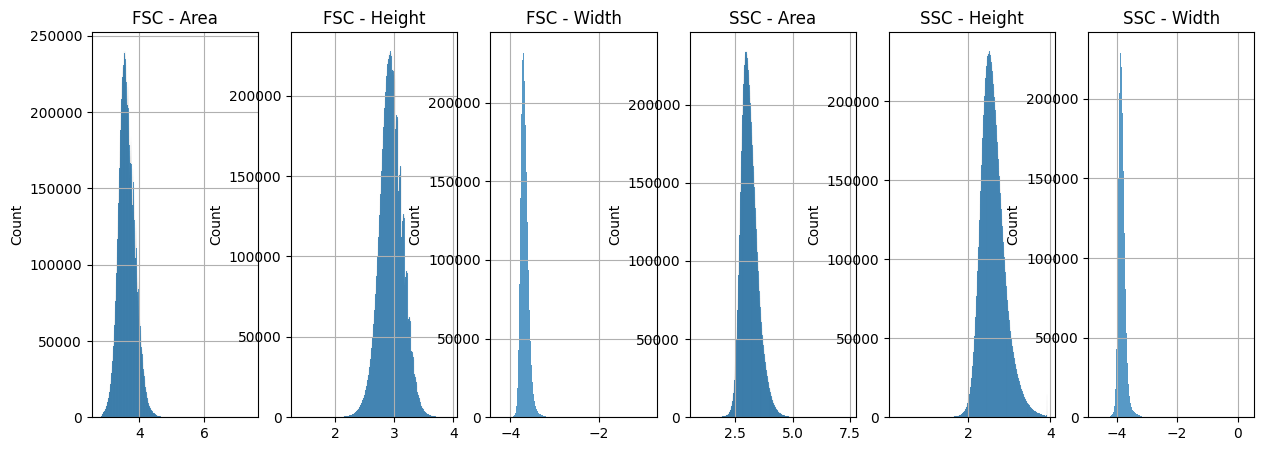

In [10]:
for key, value in X_scatter_transformed_dict.items():
    print(key)
    fig, axes = plt.subplots(1, value.shape[-1], figsize=(15, 5))
    fig.suptitle(key)
    for idx, col in enumerate(SCATTER_COLUMNS):    
        sns.histplot(value[:, idx], ax=axes[idx]) 
        axes[idx].set_title(col)
        axes[idx].grid(True)
    fig.show()
